# Steering Continuous Reasoning via Latent Intervention
### Phases 1–3: Train → Extract Truth Vector → Steer

**Before running:** Set runtime to T4 GPU → `Runtime → Change runtime type → T4 GPU`

| Phase | Script | Est. Time (T4) |
|-------|--------|----------------|
| 1 | Base CODI training | ~2 hours |
| 2 | Truth vector extraction | ~10 min |
| 3 | Steering sweep (6 alphas) | ~20 min |


## 🔧 Cell 1: Verify GPU

In [1]:
import torch

if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    mem  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'✓ GPU: {name}  ({mem:.1f} GB)')
else:
    print('✗ No GPU detected!')
    print('  Go to Runtime → Change runtime type → T4 GPU')

✓ GPU: Tesla T4  (15.6 GB)


## 📦 Cell 2: Clone Repository

In [2]:
import os

REPO = 'https://github.com/nabilanewaz/TokenSkip.git'
REPO_DIR = '/content/TokenSkip'

if os.path.exists(REPO_DIR):
    print('Repo already cloned — pulling latest changes...')
    %cd {REPO_DIR}
    !git pull
else:
    !git clone {REPO} {REPO_DIR}
    %cd {REPO_DIR}

!echo "\nRepository contents:"
!ls -la

Cloning into '/content/TokenSkip'...
remote: Enumerating objects: 402, done.
remote: Counting objects: 100% (284/284), done.
remote: Compressing objects: 100% (192/192), done.
remote: Total 402 (delta 107), reused 228 (delta 65), pack-reused 118 (from 1)
Receiving objects: 100% (402/402), 12.84 MiB | 13.59 MiB/s, done.
Resolving deltas: 100% (152/152), done.
/content/TokenSkip
\nRepository contents:
total 4832
drwxr-xr-x 14 root root    4096 Mar  4 21:59  .
drwxr-xr-x  1 root root    4096 Mar  4 21:59  ..
drwxr-xr-x  2 root root    4096 Mar  4 21:59  assets
-rw-r--r--  1 root root     469 Mar  4 21:59  bundle_codi.ps1
drwxr-xr-x  3 root root    4096 Mar  4 21:59  codi_bundle
drwxr-xr-x  3 root root    4096 Mar  4 21:59  codi_workspace
-rw-r--r--  1 root root   15696 Mar  4 21:59  colab_phases_123.ipynb
-rw-r--r--  1 root root    3114 Mar  4 21:59  COLAB_SETUP.md
-rw-r--r--  1 root root 1106080 Mar  4 21:59  colab_simple.ipynb
-rw-r--r--  1 root root     703 Mar  4 21:59 'COLAB_SIMPL IF

## 📋 Cell 3: Install Dependencies

In [ ]:
%%capture install_output
# Pin exact versions CODI requires
!pip install --force-reinstall --no-deps \
    peft==0.15.2 \
    datasets==3.6.0 \
    huggingface_hub \
    transformers==4.52.4 \
    accelerate==1.7.0 \
    safetensors

!pip install -q \
    peft==0.15.2 \
    datasets==3.6.0 \
    huggingface_hub \
    transformers==4.52.4 \
    accelerate==1.7.0 \
    safetensors

print('✓ Dependencies installed')

## ✅ Cell 4: Verify Files and Data

In [3]:
import os, pathlib

required_files = [
    'phase1_train.py',
    'phase2_extract_vector.py',
    'phase3_steer_inference.py',
    'codi_bundle/train.py',
    'codi_bundle/src/model.py',
    'datasets/gsm8k_split/llm_train.jsonl',
    'datasets/gsm8k_split/steer_train.jsonl',
    'datasets/gsm8k_split/validation.jsonl',
    'datasets/gsm8k_split/test.jsonl',
]

all_ok = True
for f in required_files:
    p = pathlib.Path(f)
    if p.exists():
        size = p.stat().st_size
        if p.suffix == '.jsonl':
            n = sum(1 for _ in open(p))
            print(f'  ✓ {f}  ({n} examples)')
        else:
            print(f'  ✓ {f}  ({size/1024:.1f} KB)')
    else:
        print(f'  ✗ MISSING: {f}')
        all_ok = False

if all_ok:
    print('\n✓ All files present. Ready to train!')
else:
    print('\n✗ Some files missing. Check your git push included all new files.')

  ✓ phase1_train.py  (14.2 KB)
  ✓ phase2_extract_vector.py  (24.0 KB)
  ✓ phase3_steer_inference.py  (29.6 KB)
  ✓ codi_bundle/train.py  (20.8 KB)
  ✓ codi_bundle/src/model.py  (20.4 KB)
  ✓ datasets/gsm8k_split/llm_train.jsonl  (300 examples)
  ✓ datasets/gsm8k_split/steer_train.jsonl  (50 examples)
  ✓ datasets/gsm8k_split/validation.jsonl  (100 examples)
  ✓ datasets/gsm8k_split/test.jsonl  (50 examples)

✓ All files present. Ready to train!


## 🔑 Cell 5: Configure Weights & Biases (Optional)

To track training metrics with wandb:
1. Go to [wandb.ai](https://wandb.ai) and get your API key
2. In Colab: Click 🔑 icon (left sidebar) → Add new secret
3. Name: `WANDB_API_KEY`, Value: your API key
4. Run the cell below

To skip wandb logging, just skip this cell.

In [4]:
# Login to Weights & Biases for experiment tracking
try:
    from google.colab import userdata
    import wandb

    # Get API key from Colab secrets
    api_key = userdata.get('WANDB_API_KEY')
    wandb.login(key=api_key)
    print('✓ Logged in to wandb')
except Exception as e:
    print(f'⚠ wandb login skipped: {e}')
    print('  Training will proceed without wandb logging')

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nabilanewaz (nabilanewaz-islamic-university-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


✓ Logged in to wandb


---
## 🚀 PHASE 1: Base Model Training
Trains CODI-GPT2 on `llm_train.jsonl` using curriculum learning.
- Stage A: discrete CoT tokens (grounds reasoning)
- Stage B: continuous latent vectors (Coconut/CODI style)

**~2 hours on T4 GPU**

In [5]:
!python phase1_train.py \
    --train-data datasets/gsm8k_split/llm_train.jsonl \
    --val-data   datasets/gsm8k_split/validation.jsonl \
    --output-dir outputs/phase1_checkpoint \
    --num_epochs 3 \
    --batch_size 4 \
    --learning_rate 2e-4 \
    --bf16


  Phase 1 — Base CODI-GPT2 Training
  Protocol: Coconut/CCoT curriculum on GSM8K

  Training examples : 300
  Output directory  : /content/TokenSkip/outputs/phase1_checkpoint
  Epochs            : 3  |  LR: 0.0002
  Batch size        : 4  |  bf16: True

[Phase 1] Checking dependencies...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 411.1/411.1 kB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 106.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.1/362.1 kB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.3/596.3 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.2/507.2 kB 44.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 112.4 MB/s eta 0:00:00
[Phase 1] ✓ Dependencies ready.
[Phase 1] ✓ codi_bundle ready: /co

In [6]:
# Monitor training progress (run this cell repeatedly while Cell above is running)
import glob, os

log_path = 'outputs/phase1_checkpoint/train_log.txt'
if os.path.exists(log_path):
    with open(log_path) as f:
        lines = f.readlines()
    print(f'Log has {len(lines)} lines. Last 20:')
    print(''.join(lines[-20:]))
else:
    print('Log not created yet — training may still be initializing...')

Log has 866 lines. Last 20:
latent5: distill_loss=0.5230933427810669
loss=1.4468308687210083, ce_loss=0.9237375259399414, distill_loss=0.5230933427810669, ce_loss_total=0.9237375259399414, distill_loss_total=0.5230933427810669, ref_ce_loss=1.6466172933578491
latent5: distill_loss=0.5542480945587158
loss=1.489619493484497, ce_loss=0.935371458530426, distill_loss=0.5542480945587158, ce_loss_total=0.935371458530426, distill_loss_total=0.5542480945587158, ref_ce_loss=1.7263213396072388
latent5: distill_loss=0.39160293340682983
loss=1.4777190685272217, ce_loss=1.086116075515747, distill_loss=0.39160293340682983, ce_loss_total=1.086116075515747, distill_loss_total=0.39160293340682983, ref_ce_loss=2.124099016189575
latent5: distill_loss=0.6248463988304138
loss=1.6000771522521973, ce_loss=0.9752307534217834, distill_loss=0.6248463988304138, ce_loss_total=0.9752307534217834, distill_loss_total=0.6248463988304138, ref_ce_loss=1.7202659845352173
latent5: distill_loss=0.5524204969406128
loss=1.417

In [7]:
# Verify Phase 1 checkpoint was saved
import glob

ckpts = glob.glob('outputs/phase1_checkpoint/**/*.safetensors', recursive=True) + \
        glob.glob('outputs/phase1_checkpoint/**/*.bin', recursive=True)

if ckpts:
    print(f'✓ Phase 1 complete! Found {len(ckpts)} checkpoint file(s):')
    for c in ckpts:
        size_mb = os.path.getsize(c) / 1e6
        print(f'    {c}  ({size_mb:.1f} MB)')
else:
    print('✗ No checkpoint found. Check train_log.txt for errors.')

meta_path = 'outputs/phase1_checkpoint/phase1_metadata.json'
if os.path.exists(meta_path):
    import json
    meta = json.load(open(meta_path))
    print(f'\nTraining metadata:')
    print(f'  n_train   : {meta["n_train"]}')
    print(f'  epochs    : {meta["epochs"]}')
    print(f'  elapsed   : {meta["elapsed_hours"]:.2f}h')

✓ Phase 1 complete! Found 4 checkpoint file(s):
    outputs/phase1_checkpoint/phase1/gpt2/ep_3/lr_0.0002/seed_42/training_args.bin  (0.0 MB)
    outputs/phase1_checkpoint/phase1/gpt2/ep_3/lr_0.0002/seed_42/pytorch_model.bin  (329.3 MB)
    outputs/phase1_checkpoint/phase1/gpt2/ep_3/lr_0.0002/seed_42/checkpoint-225/training_args.bin  (0.0 MB)
    outputs/phase1_checkpoint/phase1/gpt2/ep_3/lr_0.0002/seed_42/checkpoint-225/pytorch_model.bin  (329.3 MB)

Training metadata:
  n_train   : 300
  epochs    : 3
  elapsed   : 0.08h


---
## 🧠 PHASE 2: Truth Vector Extraction
Runs the Phase 1 model on `steer_train.jsonl`, classifies traces as H+ (correct) / H- (wrong),
then computes `v_truth = mean(H+) - mean(H-)` per latent step.

**~10 minutes on T4 GPU**

In [8]:
!python phase2_extract_vector.py \
    --steer-data datasets/gsm8k_split/steer_train.jsonl \
    --out-dir    outputs/phase2_truth_vector \
    --n-samples  5 \
    --bf16


  Phase 2 — Truth Vector Extraction
  Method: Difference-of-Means in latent space
  Steer data : datasets/gsm8k_split/steer_train.jsonl
  n_samples  : 5 (stochastic multi-pass)
  Output     : outputs/phase2_truth_vector

[Phase 2] Loaded 50 steering examples from steer_train.jsonl
2026-03-04 22:08:20.140614: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772662100.163032    3587 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772662100.170128    3587 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772662100.188648    3587 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same ta

In [9]:
# Inspect Phase 2 results
import json, os

stats_path = 'outputs/phase2_truth_vector/stats.json'
if os.path.exists(stats_path):
    stats = json.load(open(stats_path))
    print('Phase 2 Truth Vector Stats')
    print('=' * 40)
    print(f'  H+ (correct traces) : {stats["n_pos"]}')
    print(f'  H- (wrong traces)   : {stats["n_neg"]}')
    print(f'  Balance (H+/all)    : {stats["balance_ratio"]:.1%}')
    print(f'  Vector dim D        : {stats["D"]}')
    print(f'  Num latent steps L  : {stats["L"]}')
    print(f'  Global ||v_truth||  : {stats["v_truth_global_norm"]:.4f}')
    print(f'  Per-step norms      : {stats["v_truth_per_step_norms"]}')
    print(f'  Sigma per step      : {stats["sigma_per_step"]}')
else:
    print('✗ Stats not found. Phase 2 may not have completed.')

Phase 2 Truth Vector Stats
  H+ (correct traces) : 130
  H- (wrong traces)   : 120
  Balance (H+/all)    : 52.0%
  Vector dim D        : 768
  Num latent steps L  : 6
  Global ||v_truth||  : 13.4508
  Per-step norms      : [12.6077, 17.8001, 19.7955, 13.4688, 18.9611, 14.712]
  Sigma per step      : [0.7124, 1.2168, 1.3217, 1.3216, 1.3325, 1.3163]


---
## 🎯 PHASE 3: Inference-Time Steering Sweep
Sweeps α ∈ {0.0, 0.1, 0.5, 1.0, 2.0, 5.0} and evaluates on the held-out test set.

Measures:
- **Accuracy** per alpha
- **Flip Rate** — % of baseline failures corrected by steering
- **Cosine Similarity** — trajectory alignment with v_truth

**~20 minutes on T4 GPU**

In [10]:
!python phase3_steer_inference.py \
    --eval-data  datasets/gsm8k_split/test.jsonl \
    --vector-dir outputs/phase2_truth_vector \
    --out-dir    outputs/phase3_results \
    --alphas 0.0 0.1 0.5 1.0 2.0 5.0 \
    --bf16


  Phase 3 — Inference-Time Steering Sweep
  Protocol: h_{t+1} = Model(h_t) + α·σ·v̂_truth
  Eval data  : datasets/gsm8k_split/test.jsonl
  Vector dir : outputs/phase2_truth_vector
  Alphas     : [0.0, 0.1, 0.5, 1.0, 2.0, 5.0]
  Output     : outputs/phase3_results

[Phase 3] Loaded 50 eval examples from test.jsonl
[Phase 3] Using per-step v_truth (6 steps × 768D)
[Phase 3] v_truth stats: H+=130  H-=120  balance=52.0%  global_norm=13.4508
2026-03-04 22:11:58.741893: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772662318.764115    4591 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772662318.771789    4591 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been regist

In [11]:
# Display full results summary
import json, os

summary_path = 'outputs/phase3_results/summary.json'
if not os.path.exists(summary_path):
    print('Summary not found yet.')
else:
    summary = json.load(open(summary_path))
    results  = sorted(summary['results'],       key=lambda r: r['alpha'])
    flips    = {f['alpha']: f for f in summary.get('flip_analysis', [])}
    baseline_acc = next((r['accuracy'] for r in results if r['alpha'] == 0.0), None)

    print('STEERING RESULTS')
    print('=' * 75)
    print(f'{"α":>6}  {"Accuracy":>10}  {"Δ baseline":>11}  {"Flip Rate":>10}  {"Cos(h,v)":>9}')
    print('-' * 75)
    for r in results:
        a    = r['alpha']
        acc  = r['accuracy']
        cos  = r['mean_cosine_global']
        delta = (acc - baseline_acc) if baseline_acc else 0
        f    = flips.get(a, {})
        fr   = f'{f["flip_rate"]:.1%}' if f.get('flip_rate') is not None else '  baseline'
        marker = '  ← control' if a == 0.0 else ''
        print(f'{a:>6.1f}  {acc*100:>9.2f}%  {delta*100:>+10.2f}%  {fr:>10}  {cos:>9.4f}{marker}')
    print('=' * 75)

    best = max(results, key=lambda r: r['accuracy'])
    print(f'\nBest α = {best["alpha"]}  (accuracy: {best["accuracy"]:.2%})')
    if baseline_acc:
        print(f'Gain over baseline: {(best["accuracy"] - baseline_acc)*100:+.2f}%')

STEERING RESULTS
     α    Accuracy   Δ baseline   Flip Rate   Cos(h,v)
---------------------------------------------------------------------------
   0.0      36.00%       +0.00%    baseline    -0.1128  ← control
   0.1      36.00%       +0.00%        3.1%    -0.1116
   0.5      38.00%       +2.00%        3.1%    -0.1050
   1.0      36.00%       +0.00%        3.1%    -0.0972
   2.0      38.00%       +2.00%        3.1%    -0.0819
   5.0      38.00%       +2.00%        3.1%    -0.0357

Best α = 0.5  (accuracy: 38.00%)
Gain over baseline: +2.00%


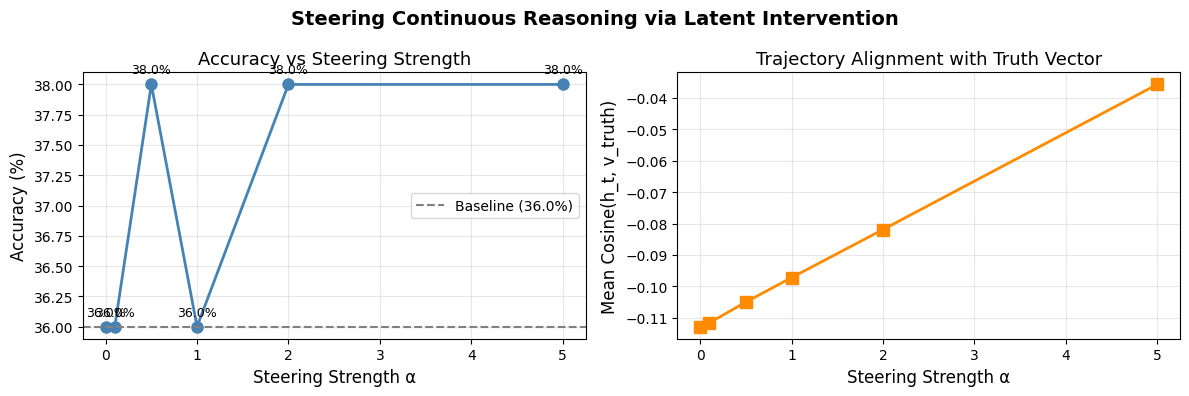

Plot saved → outputs/phase3_results/steering_plot.png


In [12]:
# Plot accuracy vs alpha
import json
import matplotlib.pyplot as plt

summary = json.load(open('outputs/phase3_results/summary.json'))
results = sorted(summary['results'], key=lambda r: r['alpha'])

alphas   = [r['alpha']          for r in results]
accs     = [r['accuracy'] * 100 for r in results]
cosines  = [r['mean_cosine_global'] for r in results]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy vs Alpha
ax = axes[0]
ax.plot(alphas, accs, 'o-', color='steelblue', linewidth=2, markersize=8)
ax.axhline(accs[0], color='gray', linestyle='--', label=f'Baseline ({accs[0]:.1f}%)')
ax.set_xlabel('Steering Strength α', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Accuracy vs Steering Strength', fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)
for a, acc in zip(alphas, accs):
    ax.annotate(f'{acc:.1f}%', (a, acc), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=9)

# Cosine Similarity vs Alpha
ax = axes[1]
ax.plot(alphas, cosines, 's-', color='darkorange', linewidth=2, markersize=8)
ax.set_xlabel('Steering Strength α', fontsize=12)
ax.set_ylabel('Mean Cosine(h_t, v_truth)', fontsize=12)
ax.set_title('Trajectory Alignment with Truth Vector', fontsize=13)
ax.grid(True, alpha=0.3)

plt.suptitle('Steering Continuous Reasoning via Latent Intervention', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/phase3_results/steering_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved → outputs/phase3_results/steering_plot.png')

---
## 💾 Save Everything to Google Drive (Optional but Recommended)

In [13]:
# Mount Google Drive to avoid losing work when session ends
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/TokenSkip_Results'
!mkdir -p {DRIVE_DIR}

!cp -r outputs/phase1_checkpoint {DRIVE_DIR}/
!cp -r outputs/phase2_truth_vector {DRIVE_DIR}/
!cp -r outputs/phase3_results {DRIVE_DIR}/

print(f'✓ All outputs backed up to {DRIVE_DIR}/')

Mounted at /content/drive
✓ All outputs backed up to /content/drive/MyDrive/TokenSkip_Results/


In [15]:
# Or download as a zip
!zip -r results.zip \
    outputs/phase1_checkpoint \
    outputs/phase2_truth_vector \
    outputs/phase3_results

from google.colab import files
files.download('results.zip')
print('✓ Download started')

updating: outputs/phase1_checkpoint/ (stored 0%)
updating: outputs/phase1_checkpoint/phase1_metadata.json (deflated 34%)
updating: outputs/phase1_checkpoint/train_log.txt (deflated 76%)
updating: outputs/phase1_checkpoint/phase1/ (stored 0%)
updating: outputs/phase1_checkpoint/phase1/gpt2/ (stored 0%)
updating: outputs/phase1_checkpoint/phase1/gpt2/ep_3/ (stored 0%)
updating: outputs/phase1_checkpoint/phase1/gpt2/ep_3/lr_0.0002/ (stored 0%)
updating: outputs/phase1_checkpoint/phase1/gpt2/ep_3/lr_0.0002/seed_42/ (stored 0%)
updating: outputs/phase1_checkpoint/phase1/gpt2/ep_3/lr_0.0002/seed_42/training_args.bin (deflated 53%)
updating: outputs/phase1_checkpoint/phase1/gpt2/ep_3/lr_0.0002/seed_42/trainer_state.json (deflated 77%)
updating: outputs/phase1_checkpoint/phase1/gpt2/ep_3/lr_0.0002/seed_42/added_tokens.json (stored 0%)
updating: outputs/phase1_checkpoint/phase1/gpt2/ep_3/lr_0.0002/seed_42/merges.txt (deflated 53%)
updating: outputs/phase1_checkpoint/phase1/gpt2/ep_3/lr_0.0002/s

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download started
